In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read in weather data from csv

cols = ['wind_direction', 'wind_speed', 'temperature', 'humidity', 'pressure',
        'rain', 'rd', 'ri', 'hail', 'hd', 'hi']

df = pd.read_csv('meteo/weather.csv', header=None, parse_dates=True, index_col=0)
df.columns = cols
df.index.name = 'date'
# Discard data before 2024-10-23 00:00:00
df = df.loc['2024-10-23 00:00:00':]
df.head()

,wind_direction,wind_speed,temperature,humidity,pressure,rain,rd,ri,hail,hd,hi
date,,,,,,,,,,,
2024-10-23 00:00:00,106.0,0.5,9.9,96.9,1009.3,0.0,0.0,0.0,0.0,0.0,0.0
2024-10-23 00:10:00,84.0,0.4,9.9,96.9,1009.3,0.0,0.0,0.0,0.0,0.0,0.0
2024-10-23 00:20:00,55.0,0.5,9.9,96.9,1009.4,0.0,0.0,0.0,0.0,0.0,0.0
2024-10-23 00:30:00,90.0,0.7,9.9,96.9,1009.6,0.0,0.0,0.0,0.0,0.0,0.0
2024-10-23 00:40:00,72.0,0.4,9.7,96.8,1009.7,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Subset the data to only include the rain column

dfrain = df[['rain']]

# Resample to hourly data
dfrainJS = dfrain.resample('h').sum()
dfrainJS.head()

,rain
date,
2024-10-23 00:00:00,0.0
2024-10-23 01:00:00,0.0
2024-10-23 02:00:00,0.0
2024-10-23 03:00:00,0.0
2024-10-23 04:00:00,0.0


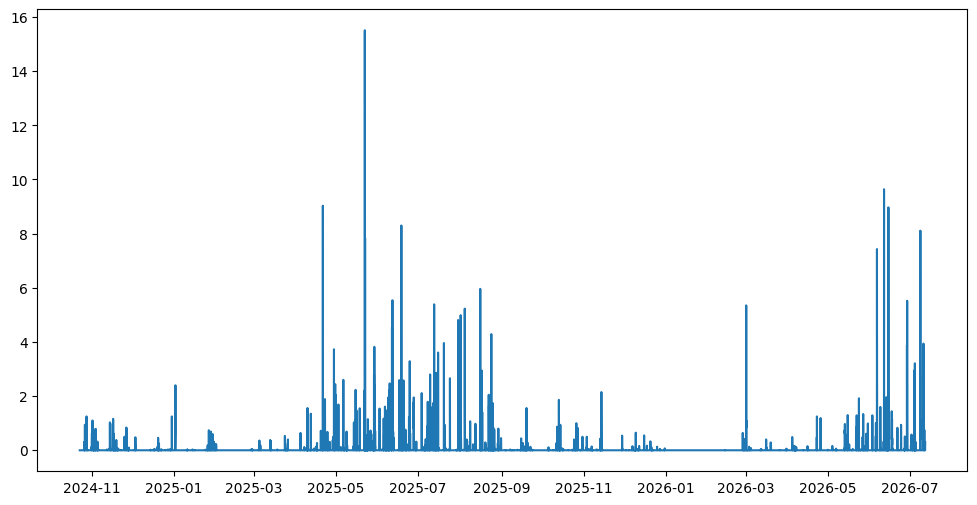

In [4]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(dfrainJS.index, dfrainJS['rain'])